# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/umemon254/Fly-rank/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [6]:
from google.colab import userdata
import os

HF_TOKEN = userdata.get("HF_TOKEN")
os.environ["HF_TOKEN"] = HF_TOKEN

print("Hugging Face token loaded:", HF_TOKEN is not None)

Hugging Face token loaded: True


In [8]:
!pip -q install duckdb pyarrow huggingface_hub

In [9]:
import duckdb
import pandas as pd
import numpy as np
import os

con = duckdb.connect()

con.execute("""
INSTALL httpfs;
LOAD httpfs;
""")

print("DuckDB connection created successfully")

DuckDB connection created successfully


In [10]:
con.execute(f"""
CREATE SECRET hf (
    TYPE HTTP,
    BEARER_TOKEN '{HF_TOKEN}'
);
""")

print("Hugging Face access configured successfully")

Hugging Face access configured successfully


In [9]:
import pandas as pd
import numpy as np

signal_df = con.execute("""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_clicks,
    gsc_impressions,
    gsc_avg_position
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
WHERE client_has_gsc IS TRUE
  AND gsc_impressions > 0
  AND gsc_avg_position IS NOT NULL
""").df()

# Create CTR safely
signal_df["ctr"] = (
    signal_df["gsc_clicks"] /
    signal_df["gsc_impressions"]
)

print("Rows:", len(signal_df))

signal_df[
    [
        "gsc_clicks",
        "gsc_impressions",
        "gsc_avg_position",
        "ctr"
    ]
].describe()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 3611061


,gsc_clicks,gsc_impressions,gsc_avg_position,ctr
count,3.611061e+06,3.611061e+06,3.611061e+06,3.611061e+06
mean,2.275874e-01,7.772164e+01,1.582665e+01,3.080748e-03
std,1.277267e+00,2.498747e+02,1.985603e+01,3.009151e-02
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,4.000000e+00,3.742120e+00,0.000000e+00
50%,0.000000e+00,1.600000e+01,7.500000e+00,0.000000e+00
75%,0.000000e+00,6.200000e+01,2.020000e+01,0.000000e+00
max,2.740000e+02,4.008400e+04,4.980000e+02,1.000000e+00


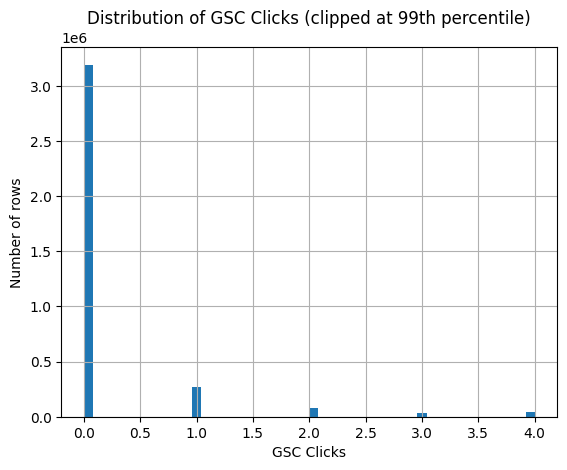

In [10]:
import matplotlib.pyplot as plt

signal_df["gsc_clicks"].clip(
    upper=signal_df["gsc_clicks"].quantile(0.99)
).hist(bins=50)

plt.title("Distribution of GSC Clicks (clipped at 99th percentile)")
plt.xlabel("GSC Clicks")
plt.ylabel("Number of rows")
plt.show()

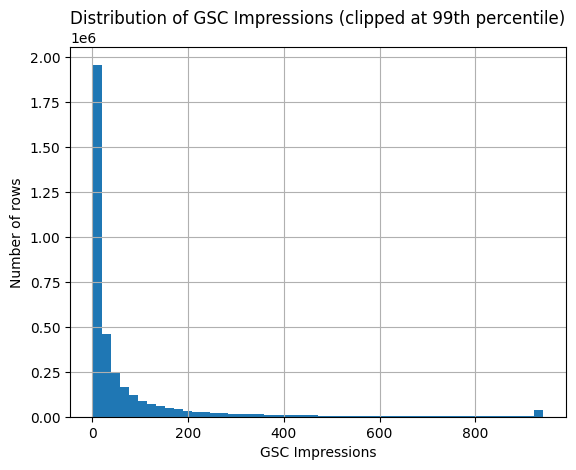

In [11]:
signal_df["gsc_impressions"].clip(
    upper=signal_df["gsc_impressions"].quantile(0.99)
).hist(bins=50)

plt.title("Distribution of GSC Impressions (clipped at 99th percentile)")
plt.xlabel("GSC Impressions")
plt.ylabel("Number of rows")
plt.show()

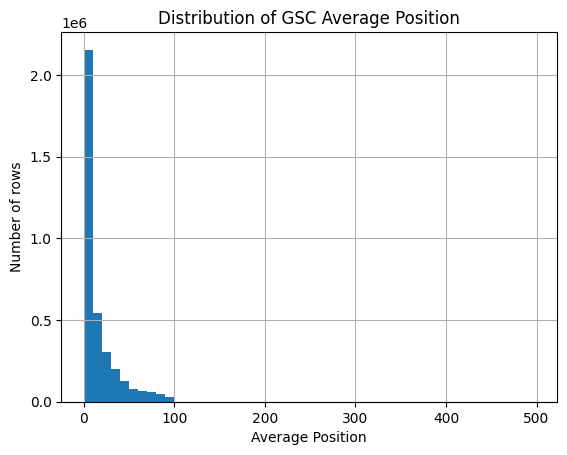

In [12]:
signal_df["gsc_avg_position"].hist(bins=50)

plt.title("Distribution of GSC Average Position")
plt.xlabel("Average Position")
plt.ylabel("Number of rows")
plt.show()

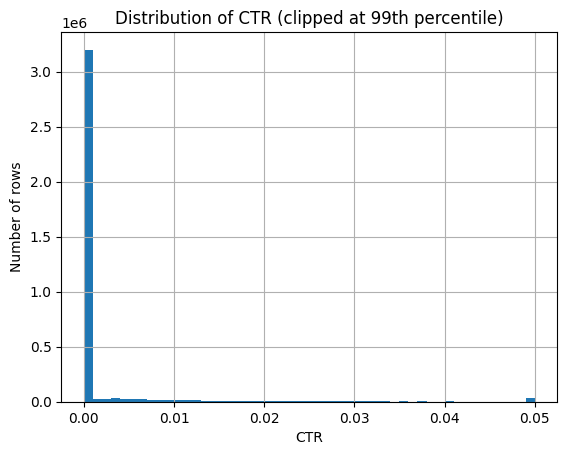

In [13]:
signal_df["ctr"].clip(
    upper=signal_df["ctr"].quantile(0.99)
).hist(bins=50)

plt.title("Distribution of CTR (clipped at 99th percentile)")
plt.xlabel("CTR")
plt.ylabel("Number of rows")
plt.show()

I examined the distributions of GSC clicks, impressions, average position, and CTR. Clicks and impressions are expected to be heavily skewed because a small number of content items can receive much more traffic than others. CTR is calculated from clicks divided by impressions, while average position is checked separately because a higher position number generally means weaker search visibility.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [14]:
test1 = signal_df.copy()

test1["impression_group"] = pd.qcut(
    test1["gsc_impressions"],
    q=4,
    duplicates="drop"
)

test1_result = (
    test1.groupby("impression_group", observed=True)
    .agg(
        rows=("gsc_clicks", "size"),
        avg_clicks=("gsc_clicks", "mean"),
        median_clicks=("gsc_clicks", "median")
    )
    .reset_index()
)

test1_result

,impression_group,rows,avg_clicks,median_clicks
0,"(0.999, 4.0]",973112,0.007227,0.0
1,"(4.0, 16.0]",868861,0.022046,0.0
2,"(16.0, 62.0]",873000,0.095276,0.0
3,"(62.0, 40084.0]",896088,0.795087,0.0


Signal 1: More impressions should generally be associated with more clicks. I grouped rows by impression quartile and compared average clicks. My verdict will be based on whether clicks generally increase across the quartiles.

In [15]:
test2 = signal_df.copy()

test2["position_group"] = pd.qcut(
    test2["gsc_avg_position"],
    q=4,
    duplicates="drop"
)

test2_result = (
    test2.groupby("position_group", observed=True)
    .agg(
        rows=("ctr", "size"),
        avg_ctr=("ctr", "mean"),
        median_ctr=("ctr", "median")
    )
    .reset_index()
)

test2_result

,position_group,rows,avg_ctr,median_ctr
0,"(-0.001, 3.742]",902766,0.004627,0.0
1,"(3.742, 7.5]",912255,0.003652,0.0
2,"(7.5, 20.2]",893304,0.002750,0.0
3,"(20.2, 498.0]",902736,0.001285,0.0


Signal 2: Better search position should generally be associated with higher CTR. Lower average-position values represent better search visibility, so I compare CTR across position groups

In [16]:
test3 = signal_df.copy()

test3["ctr_group"] = pd.qcut(
    test3["ctr"],
    q=4,
    duplicates="drop"
)

test3_result = (
    test3.groupby("ctr_group", observed=True)
    .agg(
        rows=("gsc_clicks", "size"),
        avg_clicks=("gsc_clicks", "mean"),
        median_clicks=("gsc_clicks", "median")
    )
    .reset_index()
)

test3_result

,ctr_group,rows,avg_clicks,median_clicks
0,"(-0.001, 1.0]",3611061,0.227587,0.0


Signal 3: Higher CTR should generally be associated with more clicks, but the relationship may be mixed because CTR also depends on impressions. I grouped the data by CTR quartiles and compared clicks.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [5]:
import pandas as pd
import numpy as np

signal_df = con.execute("""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_clicks,
    gsc_impressions,
    gsc_avg_position
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
WHERE client_has_gsc IS TRUE
  AND gsc_impressions > 0
  AND gsc_avg_position IS NOT NULL
""").df()

# Create CTR
signal_df["ctr"] = (
    signal_df["gsc_clicks"] /
    signal_df["gsc_impressions"]
)

print("signal_df created successfully")
print("Rows:", len(signal_df))

signal_df.head()

NameError: name 'con' is not defined

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The audit suggests that search signals should be used together instead of relying on one metric alone. Low CTR and weak average position can help identify content worth reviewing, but they are not proof that a content item needs action. The baseline should therefore be treated as a ranked decision-support queue for human review.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.